In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transformer_lens import HookedTransformer
from scipy.stats import pearsonr

import torch
import numpy as np

import json
import os

from src.utils import tuple_str_to_tuple


In [3]:
results_folder = "1_new_run_absolute_delta_head_selection"
folder_path = f"../results/{results_folder}"
os.makedirs(folder_path, exist_ok=True)


## Computing Pearson Correlation between dot product scores and causal scores


In [4]:
# Dot product head attribution
filename_dot = "2026-06-15_03-25-50_gpt2-small_train_dot_product"
random = False

with open(f'../experiment_data/5_head_attribution_scores/{filename_dot}.json') as f:
    dot_product_data = json.load(f)

dot_product_scores = dot_product_data["neuron_prompt_head_scores"]
parameters_dot_product = dot_product_data["parameters"]


In [5]:
# Activation Steering head attribution
filename_causal = "2026-06-25_17-53-49_gpt2-small_train_activation_steering"
random = False

with open(f'../experiment_data/5_head_attribution_scores/{filename_causal}.json') as f:
    activation_steering_data = json.load(f)

activation_steering_scores = activation_steering_data["neuron_prompt_head_scores"]
parameters_activation_steering = activation_steering_data["parameters"]

In [6]:
model_name = parameters_activation_steering["model_name"]

save_path = f"{folder_path}/{model_name}"
if(random):
    save_path += "-random"
os.makedirs(save_path, exist_ok=True)

In [23]:
def get_base_files(filename_dot, filename_causal):
    return_str = f'file used for dot-product head selection: "{filename_dot}.json" \n'
    return_str += f'file used for causal head selection: "{filename_causal}.json" \n'
    return return_str
with open(f'{save_path}/config.txt', 'w') as f:
    f.write(get_base_files(filename_dot, filename_causal))


In [8]:
parameters_dot_product == parameters_activation_steering

True

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
neurons = dot_product_scores.keys()
neurons2 = activation_steering_scores.keys()
neurons==neurons2

True

In [11]:
model = HookedTransformer.from_pretrained(
    model_name,
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    # refactor_factored_attn_matrices=True,
    device=device,
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [12]:
# Compute Pearson correlation
dot_scores = []
delta_scores = []

for neuron in neurons:
    for prompt in dot_product_scores[neuron].keys():
        for all_heads_idx in dot_product_scores[neuron][prompt].keys():
            dot_scores.append(dot_product_scores[neuron][prompt][all_heads_idx])
            delta_scores.append(activation_steering_scores[neuron][prompt][all_heads_idx])

corr, p_value = pearsonr(dot_scores, delta_scores)
print(f"Pearson r = {corr:.3f}, p = {p_value:.3e}")

Pearson r = 0.107, p = 0.000e+00


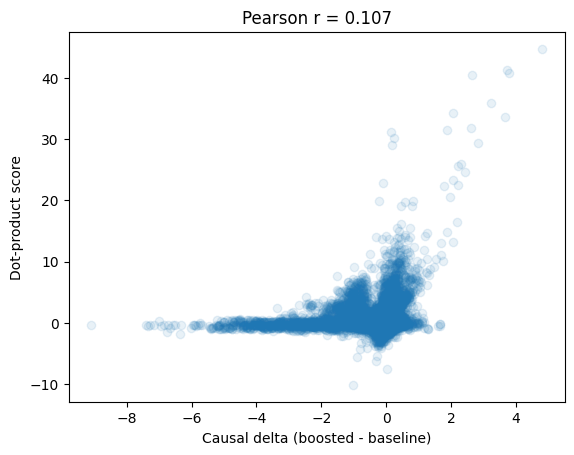

In [13]:
import matplotlib.pyplot as plt

plt.scatter(delta_scores, dot_scores, alpha=0.1)
plt.ylabel("Dot-product score")
plt.xlabel("Causal delta (boosted - baseline)")
plt.title(f"Pearson r = {corr:.3f}")

save_path = f"{folder_path}/{model_name}"
if(random):
    save_path += "-random"
os.makedirs(save_path, exist_ok=True)
filename = "pearson_correlation.pdf"
plt.savefig(os.path.join(save_path, filename))

plt.show()


# Comparison of active heads

In [14]:
filename_causal = "2026-06-25_17-53-49_gpt2-small_train"
with open(f'../experiment_data/4_new_head_attributions/{filename_causal}.json', 'r') as f:
    causal_head_attributions = json.load(f)['head_attributions']


filename_dot_product = "2026-06-15_03-25-48_gpt2-small_train"
with open(f'../experiment_data/4_head_attributions/{filename_dot_product}.json', 'r') as f:
    dot_product_head_attributions = json.load(f)['head_attributions']


In [15]:
causal_head_attributions

{'(9, 5)': {' not only become an advocate for yourself, but for others as': [118,
   88,
   53,
   106,
   93,
   40,
   87,
   68,
   97,
   61,
   30],
  'I\'m so glad that Satchel stepped up to help and that he did it with Tarah."Others have stepped up as': [87,
   92,
   34,
   106,
   118,
   105],
  ' love being a part of this and I hope you do': [69,
   72,
   101,
   118,
   42,
   61,
   78,
   77,
   71],
  ' not limited to just music however, but other areas of the entertainment business as': [88,
   118,
   69,
   34,
   47,
   100,
   72],
  ' First, just as you can pass a string or a number as an argument to a function, so': [118,
   16,
   40],
  ' as well?  Not only phone but my iPad as': [88, 118, 22, 93],
  ' has been microchipped and I would encourage other owners to do the': [118,
   69,
   101,
   34,
   65,
   87],
  ' not just motivated to achieve their own success, but to help you achieve yours as': [88,
   34,
   118,
   69,
   93,
   106,
   90,
   55,
   77,


In [16]:
len(dot_product_head_attributions)==len(causal_head_attributions)

True

### Aggregating TP, TN, FN and FP accross all neurons


In [40]:
def get_overall_metrics(neuron_results):
    overall_tp = 0
    overall_tn = 0
    overall_fp = 0
    overall_fn = 0
    for neuron in neuron_results:
        fp = neuron_results[neuron]['fp']
        tp = neuron_results[neuron]['tp']
        tn = neuron_results[neuron]['tn']
        fn = neuron_results[neuron]['fn']

        overall_tp += tp
        overall_fn += fn
        overall_fp += fp
        overall_tn += tn
        
    acc = (overall_tp + overall_tn) / (overall_tp + overall_tn + overall_fp + overall_fn)
    precision = overall_tp / (overall_tp + overall_fp)
    recall = overall_tp / (overall_tp + overall_fn) 
    fpr = overall_fp / (overall_fp + overall_tn)

    overall_metrics = {'accuracy' : acc, 'recall' : recall, 'precision': precision, 'false_positive_rate': fpr}
    return overall_metrics

#overall_metrics = get_overall_metrics(neuron_results)
#overall_metrics

### Aggregating computed metrics accross all neurons

In [41]:
def get_per_neuron_metrics(neuron_results):
    neuron_metrics = {}
    for neuron in neuron_results:
        fp = neuron_results[neuron]['fp']
        tp = neuron_results[neuron]['tp']
        tn = neuron_results[neuron]['tn']
        fn = neuron_results[neuron]['fn']
        acc = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn) 
        fpr = fp / (fp + tn)
        neuron_metrics[neuron] = {'accuracy' : acc, 'recall' : recall, 'precision': precision, 'false_positive_rate': fpr}
    return neuron_metrics

#per_neuron_metrics = get_per_neuron_metrics(neuron_results)
#per_neuron_metrics

In [42]:
sum_acc = 0
sum_recall = 0
sum_precision = 0
sum_fpr = 0

neurons_qtt = len(per_neuron_metrics)
for neuron in per_neuron_metrics.keys():
    sum_recall += per_neuron_metrics[neuron]['recall']
    sum_acc += per_neuron_metrics[neuron]['accuracy']
    sum_precision += per_neuron_metrics[neuron]['precision']
    sum_fpr += per_neuron_metrics[neuron]['false_positive_rate']

avg_recall = sum_recall/neurons_qtt
avg_acc = sum_acc/neurons_qtt
avg_precision = sum_precision/neurons_qtt
avg_fpr = sum_fpr/neurons_qtt

avg_overall_metrics = {'accuracy' : sum_acc/neurons_qtt, 'recall' : sum_recall/neurons_qtt, 'precision': sum_precision/neurons_qtt, 'false_positive_rate': sum_fpr/neurons_qtt}
avg_overall_metrics

NameError: name 'per_neuron_metrics' is not defined

### Agreggating metric across prompts and then across neurons

* Dealt with division by zero by skipping prompts with either undefined precision, recall or false positive rate
* It yielded an exclusion of 83 prompts out of 1102 (7.5%)
* If I only choose precision and recall, the same prompts will be excluded

In [18]:
neuron_prompt_results = {}
for neuron in causal_head_attributions.keys():
    neuron_prompt_results[neuron] = {}
    for prompt in causal_head_attributions[neuron].keys():
        active_heads_causal = causal_head_attributions[neuron][prompt]
        active_heads_dot_product = dot_product_head_attributions[neuron][prompt]

        neuron_layer, neuron_idx =  tuple_str_to_tuple(neuron)
        tp = 0 
        fp = 0
        tn = model.cfg.n_heads * neuron_layer
        fn = 0
        for head in active_heads_dot_product:
            if head in active_heads_causal:
                tp+=1
                tn-=1
            else:
                fp += 1
                tn-=1
        for head in active_heads_causal:
            if head not in active_heads_dot_product:
                fn += 1
                tn-=1
        neuron_prompt_results[neuron][prompt] = {'tp' : tp, 'tn': tn, 'fp': fp, 'fn': fn}
neuron_prompt_results


{'(9, 5)': {' not only become an advocate for yourself, but for others as': {'tp': 4,
   'tn': 96,
   'fp': 1,
   'fn': 7},
  'I\'m so glad that Satchel stepped up to help and that he did it with Tarah."Others have stepped up as': {'tp': 2,
   'tn': 98,
   'fp': 4,
   'fn': 4},
  ' love being a part of this and I hope you do': {'tp': 4,
   'tn': 96,
   'fp': 3,
   'fn': 5},
  ' not limited to just music however, but other areas of the entertainment business as': {'tp': 2,
   'tn': 100,
   'fp': 1,
   'fn': 5},
  ' First, just as you can pass a string or a number as an argument to a function, so': {'tp': 1,
   'tn': 100,
   'fp': 5,
   'fn': 2},
  ' as well?  Not only phone but my iPad as': {'tp': 4,
   'tn': 104,
   'fp': 0,
   'fn': 0},
  ' has been microchipped and I would encourage other owners to do the': {'tp': 3,
   'tn': 99,
   'fp': 3,
   'fn': 3},
  ' not just motivated to achieve their own success, but to help you achieve yours as': {'tp': 3,
   'tn': 95,
   'fp': 2,
   'fn':

In [19]:
def get_per_prompt_metrics(neuron_prompt_results):
    neuron_prompt_metrics = {}
    cnt=0
    for neuron in neuron_prompt_results:
        neuron_prompt_metrics[neuron] = {}
        for prompt in neuron_prompt_results[neuron].keys():
            fp = neuron_prompt_results[neuron][prompt]['fp']
            tp = neuron_prompt_results[neuron][prompt]['tp']
            tn = neuron_prompt_results[neuron][prompt]['tn']
            fn = neuron_prompt_results[neuron][prompt]['fn']
            acc = (tp + tn) / (tp + tn + fp + fn)
            precision = tp / (tp + fp) if(tp+fp)>0 else None
            recall = tp / (tp + fn) if (tp+fn)>0 else None
            fpr = fp / (fp + tn) if (fp + tn)>0 else None
            #if(fpr is None or recall is None or precision is None):
            #    continue
            if(recall is None or precision is None):
                cnt+=1
                continue
            neuron_prompt_metrics[neuron][prompt] = {'accuracy' : acc, 'recall' : recall, 'precision': precision, 'false_positive_rate': fpr}
    print(cnt)
    return neuron_prompt_metrics

per_prompt_metrics = get_per_prompt_metrics(neuron_prompt_results)
per_prompt_metrics

64


{'(9, 5)': {' not only become an advocate for yourself, but for others as': {'accuracy': 0.9259259259259259,
   'recall': 0.36363636363636365,
   'precision': 0.8,
   'false_positive_rate': 0.010309278350515464},
  'I\'m so glad that Satchel stepped up to help and that he did it with Tarah."Others have stepped up as': {'accuracy': 0.9259259259259259,
   'recall': 0.3333333333333333,
   'precision': 0.3333333333333333,
   'false_positive_rate': 0.0392156862745098},
  ' love being a part of this and I hope you do': {'accuracy': 0.9259259259259259,
   'recall': 0.4444444444444444,
   'precision': 0.5714285714285714,
   'false_positive_rate': 0.030303030303030304},
  ' not limited to just music however, but other areas of the entertainment business as': {'accuracy': 0.9444444444444444,
   'recall': 0.2857142857142857,
   'precision': 0.6666666666666666,
   'false_positive_rate': 0.009900990099009901},
  ' First, just as you can pass a string or a number as an argument to a function, so': {

In [20]:
neuron_prompt_metrics = {}
for neuron in per_prompt_metrics:
    acc_sum = 0
    recall_sum = 0
    precision_sum = 0
    fpr_sum = 0
    prompts_qtt = 0
    for prompt in per_prompt_metrics[neuron].keys():
        if prompt not in per_prompt_metrics[neuron]:
            continue
        acc = per_prompt_metrics[neuron][prompt]['accuracy']
        recall = per_prompt_metrics[neuron][prompt]['recall']
        precision = per_prompt_metrics[neuron][prompt]['precision']
        fpr = per_prompt_metrics[neuron][prompt]['false_positive_rate']
        
        acc_sum += acc
        recall_sum += recall
        precision_sum += precision
        fpr_sum += fpr
        prompts_qtt += 1
    # No need to worry about prompts_qtt becoming 0 since previous analysis in "check_train_test_prompts.ipynb" showed no neuron has 0 train prompts after truncation
    neuron_prompt_metrics[neuron] = {'accuracy' : acc_sum/prompts_qtt, 'recall' : recall_sum/prompts_qtt, 'precision': precision_sum/prompts_qtt, 'false_positive_rate': fpr_sum/prompts_qtt}
neuron_prompt_metrics
    

{'(9, 5)': {'accuracy': 0.9282407407407407,
  'recall': 0.34786976911976913,
  'precision': 0.5241666666666667,
  'false_positive_rate': 0.024798047765134286},
 '(9, 1616)': {'accuracy': 0.9310185185185184,
  'recall': 0.2875829725829726,
  'precision': 0.35464285714285715,
  'false_positive_rate': 0.029751130311248576},
 '(9, 1985)': {'accuracy': 0.9517543859649124,
  'recall': 0.4156223893065998,
  'precision': 0.5132832080200501,
  'false_positive_rate': 0.021804823829119864},
 '(9, 1496)': {'accuracy': 0.9590643274853798,
  'recall': 0.6068295739348372,
  'precision': 0.5596491228070176,
  'false_positive_rate': 0.022143036692427762},
 '(9, 2513)': {'accuracy': 0.935185185185185,
  'recall': 0.3416078073972811,
  'precision': 0.6424812030075188,
  'false_positive_rate': 0.01515014448765127},
 '(9, 1047)': {'accuracy': 0.953125,
  'recall': 0.48735119047619047,
  'precision': 0.6437499999999999,
  'false_positive_rate': 0.017077780920893133},
 '(9, 2209)': {'accuracy': 0.93452380952

In [21]:
overall_acc_sum = 0
overall_recall_sum = 0
overall_precision_sum = 0
overall_fpr_sum = 0

for neuron in neuron_prompt_metrics.keys():
    overall_acc_sum += neuron_prompt_metrics[neuron]['accuracy']
    overall_recall_sum += neuron_prompt_metrics[neuron]['recall']
    overall_precision_sum += neuron_prompt_metrics[neuron]['precision']
    overall_fpr_sum += neuron_prompt_metrics[neuron]['false_positive_rate']

avg_overall_metrics = {'accuracy' : overall_acc_sum/len(neuron_prompt_metrics.keys()), 'recall' : overall_recall_sum/len(neuron_prompt_metrics.keys()), 'precision': overall_precision_sum/len(neuron_prompt_metrics.keys()), 'false_positive_rate': overall_fpr_sum/len(neuron_prompt_metrics.keys())}

os.makedirs(save_path, exist_ok=True)
with open(f"{save_path}/head_attribution_metrics.txt", "w") as f:
    for metric, value in avg_overall_metrics.items():
        f.write(f'{metric}:{value}\n')